# ***CNN Model Immplementation***

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Path to your zip file
zip_path = "/content/drive/MyDrive/apple_disease_classification.zip"

***Extract dataset***

In [3]:
# Extract dataset
import zipfile
import os

extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)

Dataset extracted to: /content/dataset


In [4]:
# Set dataset directory
data_dir = extract_path

***Define separate paths***

In [5]:
# Define separate paths
train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')

print("Train Path:", train_dir)
print("Test Path:", test_dir)

Train Path: /content/dataset/train
Test Path: /content/dataset/test


***Total Images***

In [6]:
# Count total images
import os

def count_images(folder):
    total = 0
    if not os.path.exists(folder):
        print(f"Warning: Folder not found: {folder}. Returning 0.")
        return 0
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        if os.path.isdir(label_path):
            total += len(os.listdir(label_path))
    return total

# Assuming 'extract_path' is defined in a previous cell as '/content/dataset'
# The zip file likely extracted to '/content/dataset/apple_disease_classification'
base_data_dir = os.path.join(extract_path, 'apple_disease_classification')
# Adjusting for potential case sensitivity: checking for 'Train' and 'Test'
train_dir = os.path.join(base_data_dir, 'Train') # Changed 'train' to 'Train'
test_dir = os.path.join(base_data_dir, 'Test')   # Changed 'test' to 'Test'

print("Total Train Images:", count_images(train_dir))
print("Total Test Images:", count_images(test_dir))

Total Train Images: 382
Total Test Images: 120


***class names***

In [7]:
# Show class names
classes = os.listdir(train_dir)
print("Classes:", classes)
print("Number of classes:", len(classes))

Classes: ['Blotch_Apple', 'Scab_Apple', 'Rot_Apple', 'Normal_Apple']
Number of classes: 4


***Class Distribution***

In [24]:
def count_images(folder):
    for label in os.listdir(folder):
        label_path = os.path.join(folder, label)
        print(f"{label}: {len(os.listdir(label_path))}")

print("Train Data:")
count_images(train_dir)

print("\nTest Data:")
count_images(test_dir)

Train Data:
Blotch_Apple: 116
Scab_Apple: 85
Rot_Apple: 114
Normal_Apple: 67

Test Data:
Blotch_Apple: 30
Scab_Apple: 28
Rot_Apple: 38
Normal_Apple: 24


***Load Dataset***

In [25]:
import tensorflow as tf

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_data.class_names
print("Classes:", class_names)

Found 382 files belonging to 4 classes.
Found 120 files belonging to 4 classes.
Classes: ['Blotch_Apple', 'Normal_Apple', 'Rot_Apple', 'Scab_Apple']


***Check empty folders***

In [8]:
# Check empty folders
for cls in classes:
    path = os.path.join(train_dir, cls)
    if len(os.listdir(path)) == 0:
        print(f"Empty class found: {cls}")

***Label Distribution***

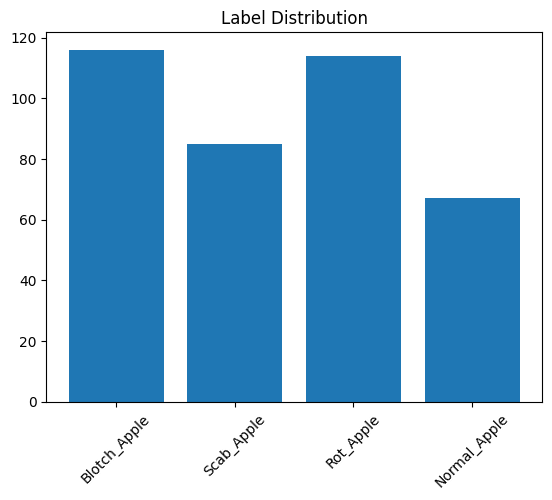

In [9]:
import matplotlib.pyplot as plt

counts = []
for cls in classes:
    counts.append(len(os.listdir(os.path.join(train_dir, cls))))

plt.bar(classes, counts)
plt.xticks(rotation=45)
plt.title("Label Distribution")
plt.show()

In [10]:
# Balance Dataset (Optional - Augmentation)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Augmentation to handle imbalance
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

***Classification***

In [11]:
# Classification (Image Classification Setup)

# Load images
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 382 images belonging to 4 classes.
Found 120 images belonging to 4 classes.


In [12]:
# Preprocessing
# Already done using rescale=1./255 in ImageDataGenerator

In [13]:
# Automatically handled by flow_from_directory
print(train_data.class_indices)

{'Blotch_Apple': 0, 'Normal_Apple': 1, 'Rot_Apple': 2, 'Scab_Apple': 3}


***Model Sequential***

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# CNN Layers
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(len(classes), activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

***Epoches***

In [15]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 43s 3s/step - accuracy: 0.3141 - loss: 3.1182 - val_accuracy: 0.4167 - val_loss: 1.2490
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5052 - loss: 1.1808 - val_accuracy: 0.5583 - val_loss: 1.0643
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 55s 5s/step - accuracy: 0.5393 - loss: 1.0686 - val_accuracy: 0.5583 - val_loss: 1.1872
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.6126 - loss: 0.9703 - val_accuracy: 0.5667 - val_loss: 1.1300
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.6859 - loss: 0.8962 - val_accuracy: 0.5333 - val_loss: 1.4565
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.6440 - loss: 0.8842 - val_accuracy: 0.6500 - val_loss: 0.9454
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.6806 - loss: 0.8283 - val_accuracy: 0.6583 - val_loss: 0.9160
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.7225 - loss: 0.7235 - val_accuracy: 0.6083 - val_loss:

***Train/Test Accuracy***

In [16]:
# Accuracy (Train/Test)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print("Train Accuracy:", train_acc*100)
print("Test Accuracy:", val_acc*100)

Train Accuracy: 79.31936979293823
Test Accuracy: 63.333332538604736


***Confusion Matrix***

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 615ms/step


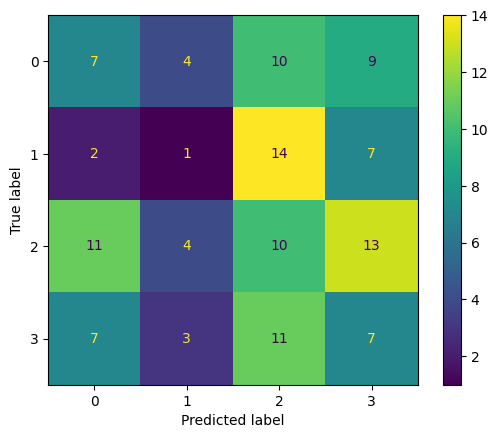

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

***Prediction***

In [18]:
# Prediction (Single Image)

from tensorflow.keras.preprocessing import image
import numpy as np # numpy needs to be imported for np.expand_dims
import os

# A sample image from the dataset, assuming 'test_dir' and 'classes' are defined
# You might need to adjust this path to an actual image within your extracted dataset
# For example, let's pick the first image from the first class in the test set

# Ensure test_dir and classes are accessible (they are from previous cells)
# test_dir = '/content/dataset/apple_disease_classification/Test'
# classes = ['Blotch_Apple', 'Scab_Apple', 'Rot_Apple', 'Normal_Apple']

# Construct a path to a sample image
# For demonstration, picking the first image in the first class of the test directory
if os.path.exists(test_dir) and classes:
    first_class_dir = os.path.join(test_dir, classes[0])
    if os.path.exists(first_class_dir):
        image_files = [f for f in os.listdir(first_class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if image_files:
            img_path = os.path.join(first_class_dir, image_files[0])
            print(f"Using sample image: {img_path}")
        else:
            img_path = '/content/sample.jpg' # Fallback if no images found
            print("No images found in the first class of the test directory. Using default path. Please upload 'sample.jpg' or provide a valid path.")
    else:
        img_path = '/content/sample.jpg' # Fallback if class directory not found
        print("First class directory not found. Using default path. Please upload 'sample.jpg' or provide a valid path.")
else:
    img_path = '/content/sample.jpg' # Fallback if test_dir or classes not defined
    print("Test directory or classes not defined. Using default path. Please upload 'sample.jpg' or provide a valid path.")


# img_path = '/content/sample.jpg'  # change path - ORIGINAL LINE

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = classes[np.argmax(prediction)]

print("Predicted Class:", predicted_class)

Using sample image: /content/dataset/apple_disease_classification/Test/Blotch_Apple/125.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
Predicted Class: Blotch_Apple


***Loss & Accuracy Graphs***

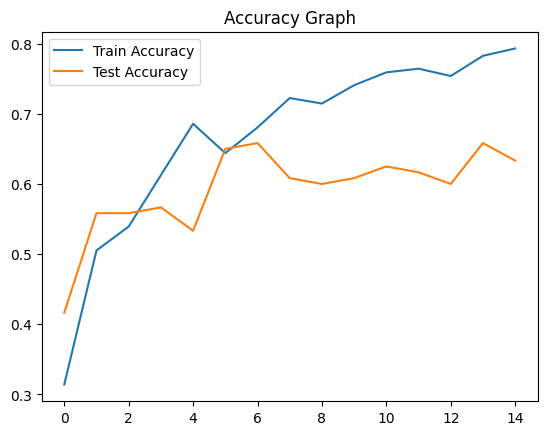

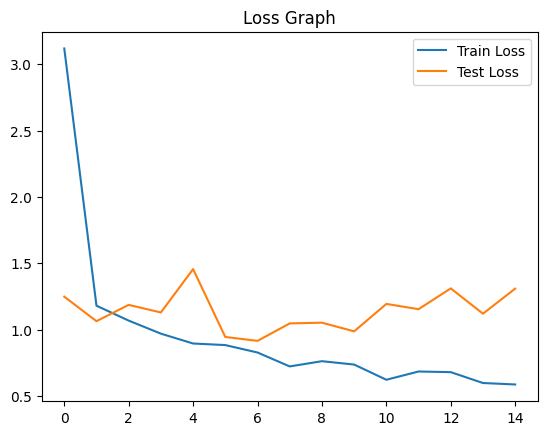

In [19]:
# Accuracy Graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

***Accuracy Comparison Graph***

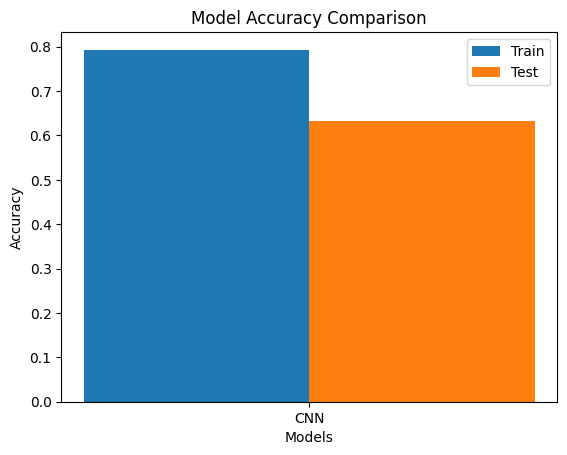

In [20]:
# # Accuracy Comparison Graph

import matplotlib.pyplot as plt
import numpy as np

models = ['CNN']
train_scores = [train_acc]
test_scores = [val_acc]

x = np.arange(len(models))
width = 0.35  # bar ki width

# Left aur right shift
plt.bar(x - width/2, train_scores, width=width, label='Train')
plt.bar(x + width/2, test_scores, width=width, label='Test')

plt.xticks(x, models)
plt.legend()
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

***Check Overfitting / Underfitting***

In [21]:
# Check Overfitting / Underfitting (Numerical)

# Get final accuracies
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

print("Train Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Train Loss:", train_loss)
print("Validation Loss:", val_loss)

# Check condition
if train_acc > 0.90 and val_acc < train_acc - 0.1:
    print("⚠️ Overfitting Detected")
elif train_acc < 0.70 and val_acc < 0.70:
    print("⚠️ Underfitting Detected")
else:
    print("✅ Model is Balanced")

Train Accuracy: 0.7931936979293823
Validation Accuracy: 0.6333333253860474
Train Loss: 0.5875757932662964
Validation Loss: 1.3094305992126465
✅ Model is Balanced


***Graph to Visualize***

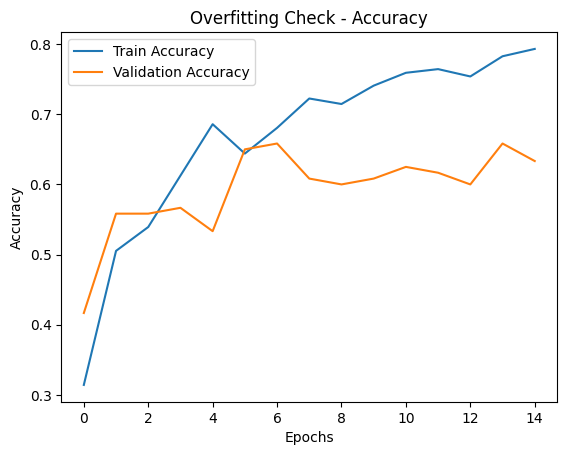

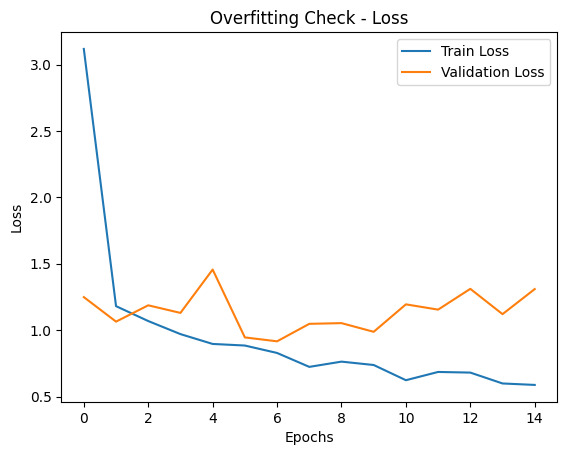

In [22]:
# Graph to Visualize Overfitting

import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Overfitting Check - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Overfitting Check - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

***Data Augmentation***

In [23]:
# Data Augmentation (Strong Fix)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    shear_range=0.2
)

In [26]:
model.save("apple_model.h5")